In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import random

In [2]:
df = pd.read_csv("Data/Testing/test_dataset.csv")
print(df.shape)
print(df['label'].value_counts())

(2029, 3)
label
love       673
sadness    532
anger      410
joy        250
fear       164
Name: count, dtype: int64


In [3]:
# split 80:20 stratified, sama seperti model utama
train_baseline, test_baseline = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Train baseline: {len(train_baseline)}")
print(f"Test baseline: {len(test_baseline)}")
print()
print("Train distribution:")
print(train_baseline['label'].value_counts())
print()
print("Test distribution:")
print(test_baseline['label'].value_counts())

Train baseline: 1623
Test baseline: 406

Train distribution:
label
love       538
sadness    426
anger      328
joy        200
fear       131
Name: count, dtype: int64

Test distribution:
label
love       135
sadness    106
anger       82
joy         50
fear        33
Name: count, dtype: int64


In [4]:
label2id = {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4}
id2label = {v: k for k, v in label2id.items()}

train_baseline['label_id'] = train_baseline['label'].map(label2id)
test_baseline['label_id'] = test_baseline['label'].map(label2id)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(list(label2id.values())),
    y=train_baseline['label_id'].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

[0.98963415 2.4778626  1.623      0.60334572 0.76197183]


# Model

In [5]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

/home/somitemp/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['tweet'].tolist()
        self.labels = df['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = EmotionDataset(train_baseline, tokenizer)
test_dataset = EmotionDataset(test_baseline, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 102
Test batches: 26


In [7]:
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch.nn as nn

In [8]:
SEED = 3093
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_baseline = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)
model_baseline = model_baseline.to(device)

class_weights_tensor = class_weights_tensor.to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

EPOCHS = 3
optimizer = AdamW(model_baseline.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"Total steps: {total_steps}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 24458.37it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total steps: 306


In [10]:
from tqdm import tqdm
from sklearn.metrics import f1_score

In [11]:
train_sub_baseline, val_baseline = train_test_split(
    train_baseline, test_size=0.2, random_state=42, stratify=train_baseline['label']
)

train_sub_dataset = EmotionDataset(train_sub_baseline, tokenizer)
val_dataset = EmotionDataset(val_baseline, tokenizer)

train_sub_loader = DataLoader(train_sub_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train subset: {len(train_sub_baseline)}, Val: {len(val_baseline)}")

Train subset: 1298, Val: 325


In [12]:
def evaluate(model, loader, loss_fn):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    avg_loss = total_loss / len(loader)
    return avg_loss, f1

In [16]:
SEED = 3093
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [17]:
# reset model
model_baseline = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)
model_baseline = model_baseline.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 33062.65it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
EPOCHS_SEARCH = 7
optimizer = AdamW(model_baseline.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_sub_loader) * EPOCHS_SEARCH
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

best_f1 = 0
best_epoch = 0

for epoch in range(EPOCHS_SEARCH):
    model_baseline.train()
    total_train_loss = 0

    for batch in tqdm(train_sub_loader, desc=f"Epoch {epoch+1}/{EPOCHS_SEARCH}"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_baseline(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_baseline.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_sub_loader)
    val_loss, val_f1 = evaluate(model_baseline, val_loader, loss_fn)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        torch.save(model_baseline.state_dict(), "best_baseline_stage1.pt")

print(f"\nBest epoch: {best_epoch} dengan Val F1: {best_f1:.4f}")

Epoch 1/7: 100%|██████████| 82/82 [00:17<00:00,  4.66it/s]


Epoch 1 | Train Loss: 1.3834 | Val Loss: 1.1057 | Val F1: 0.4946


Epoch 2/7: 100%|██████████| 82/82 [00:18<00:00,  4.46it/s]


Epoch 2 | Train Loss: 0.8287 | Val Loss: 0.9049 | Val F1: 0.6464


Epoch 3/7: 100%|██████████| 82/82 [00:19<00:00,  4.17it/s]


...

Epoch 5 | Train Loss: 0.0905 | Val Loss: 1.2892 | Val F1: 0.6864


Epoch 6/7: 100%|██████████| 82/82 [00:21<00:00,  3.75it/s]


Epoch 6 | Train Loss: 0.0318 | Val Loss: 1.4034 | Val F1: 0.6898


Epoch 7/7: 100%|██████████| 82/82 [00:22<00:00,  3.73it/s]


Epoch 7 | Train Loss: 0.0144 | Val Loss: 1.3261 | Val F1: 0.7069

Best epoch: 7 dengan Val F1: 0.7069


In [19]:
model_baseline_final = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)
model_baseline_final = model_baseline_final.to(device)

BEST_EPOCH = 2

optimizer = AdamW(model_baseline_final.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * BEST_EPOCH
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

for epoch in range(BEST_EPOCH):
    model_baseline_final.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{BEST_EPOCH}"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_baseline_final(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_baseline_final.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{BEST_EPOCH} | Train Loss: {avg_train_loss:.4f}")

torch.save(model_baseline_final.state_dict(), "baseline_model_final.pt")
print("Saved: baseline_model_final.pt")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 33710.28it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/2: 100%|██████████| 102/102 [00:21<00:00,  4.65it/s]


Epoch 1/2 | Train Loss: 1.2737


Epoch 2/2: 100%|██████████| 102/102 [00:23<00:00,  4.35it/s]


Epoch 2/2 | Train Loss: 0.7328
Saved: baseline_model_final.pt


# Evaluasi

In [20]:
from sklearn.metrics import classification_report, accuracy_score

In [21]:
model_baseline_final.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model_baseline_final(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=list(label2id.keys()), digits=4))

Accuracy: 0.7266

              precision    recall  f1-score   support

       anger     0.7531    0.7439    0.7485        82
        fear     0.7045    0.9394    0.8052        33
         joy     0.4744    0.7400    0.5781        50
        love     0.8351    0.6000    0.6983       135
     sadness     0.8019    0.8019    0.8019       106

    accuracy                         0.7266       406
   macro avg     0.7138    0.7650    0.7264       406
weighted avg     0.7548    0.7266    0.7294       406



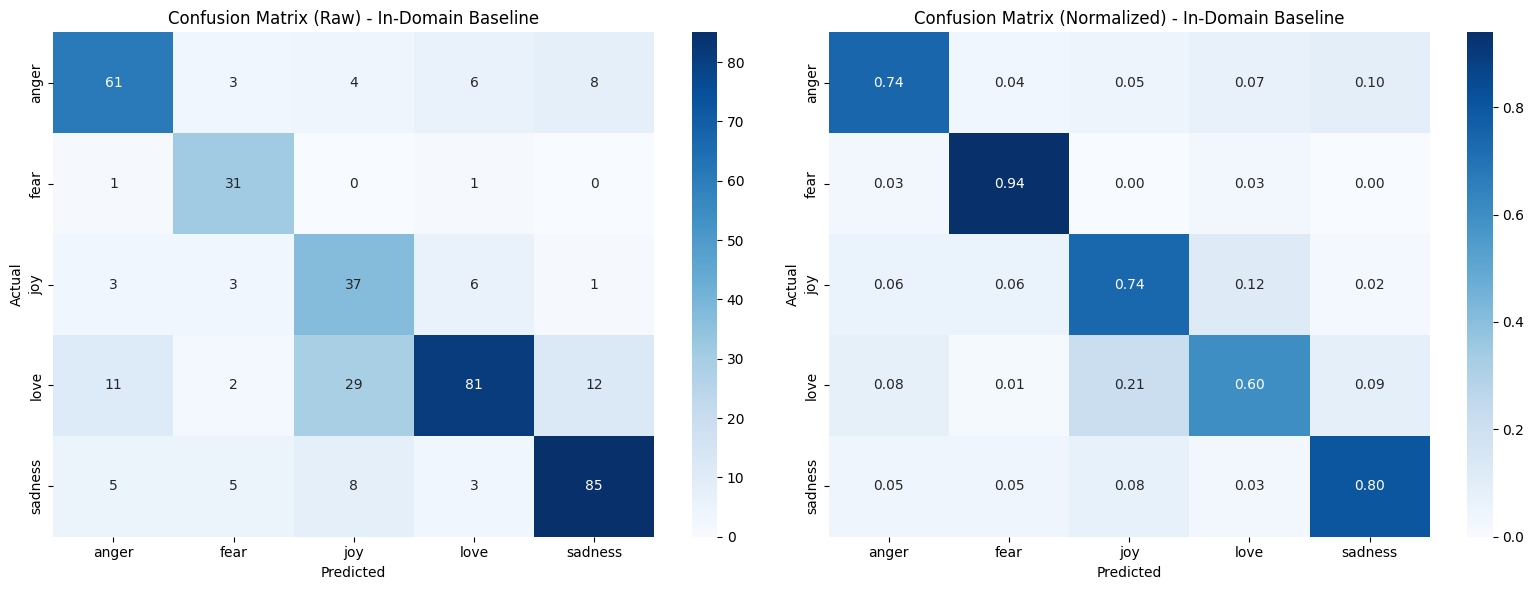

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2id.keys()),
            yticklabels=list(label2id.keys()), ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Raw) - In-Domain Baseline')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=list(label2id.keys()),
            yticklabels=list(label2id.keys()), ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized) - In-Domain Baseline')

plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150)
plt.show()